In [1]:
import numpy as np
from matplotlib import pyplot as plt
import sympy

# 1D

In [2]:
rho, g, i, u, mu, e, eb, dp, A_E, B_E, A, z, zb, zs, a, lambd = sympy.symbols(r"varrho g i U mu epsilon, epsilon_b d_p A_E B_E A_\ast z z_b z_s alpha lambda")
u0, u1, u2 = sympy.symbols("U^{(0)} U^{(1)} U^{(2)}")
u_func = u0 + u1*(z-zb) + 1/2*u2*(z-zb)**2
u1_func = u_func.diff(z)
u2_func = u_func.diff(z, 2)
display(u_func)
nu = mu / rho

constants = {
    rho: 1000,
    g: 9.81,
    i: 1/100,
    mu: 1e-3,
    dp: 1e-2,
    A_E: 180,
    B_E: 1.75,
    eb: 0.1,
    a: 1.,
    zb: -2,
    zs: -2,
    lambd: 0.15,
}

U^{(0)} + U^{(1)}*(z - z_b) + 0.5*U^{(2)}*(z - z_b)**2

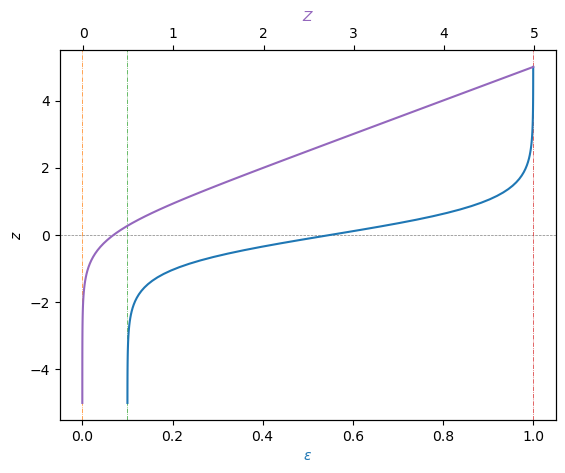

In [3]:
Z, a = sympy.symbols("Z_LS alpha")
Z_func = 1/2*(z + sympy.ln(sympy.cosh(a*z))/a)
Z_func = Z_func - Z_func.subs(dict(z=zb))
e_func = (1-eb)*Z_func.diff(z) + eb

z_arr = np.linspace(-5, 5, num=100)
fig, ax1 = plt.subplots(sharey=True)
ax2 = ax1.twiny()
ax2.grid(False)

ax1.axline((0, 0), slope=0, ls="--", c="gray", lw=0.5)
axlinestyle = dict(slope=np.inf, ls="-.", lw=0.5)
ax1.axline((0, 0), **axlinestyle, c="C1")
ax1.axline((constants[eb], 0), **axlinestyle, c="C2")
ax1.axline((1, 0), **axlinestyle, c="C3")

ax1.plot(sympy.lambdify(z, e_func.subs(constants))(z_arr), z_arr, c="C0")

ax2.plot(sympy.lambdify(z, Z_func.subs(constants))(z_arr), z_arr, c="C4")

ax1.set_xlabel(r"$\epsilon$", color="C0")
ax1.set_ylabel("$z$")
ax2.set_xlabel("$Z$", color="C4")
plt.show()

In [4]:
f = sympy.symbols("f")
K_KC = e**2 * dp**2 / (A_E * (1-e)**2)
u_SSL = g*i*K_KC/nu
display(u_SSL)

F = B_E*(1-e) / dp * rho *u**2
f_func = - mu*e_func*u_func/K_KC + F
display(sympy.Equality(f, f_func))

d_p**2*epsilon**2*g*i*varrho/(A_E*mu*(1 - epsilon)**2)

Eq(f, -A_E*mu*(1 - epsilon)**2*(epsilon_b + (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5))*(U^{(0)} + U^{(1)}*(z - z_b) + 0.5*U^{(2)}*(z - z_b)**2)/(d_p**2*epsilon**2) + B_E*U**2*varrho*(1 - epsilon)/d_p)

In [5]:
tau_v = sympy.symbols("tau_v")
tau_v_func = mu * (e_func.diff(z)*u_func + e_func*u1_func)
display(sympy.Equality(tau_v, tau_v_func))

Eq(tau_v, mu*((1 - epsilon_b)*(-0.5*alpha*sinh(alpha*z)**2/cosh(alpha*z)**2 + 0.5*alpha)*(U^{(0)} + U^{(1)}*(z - z_b) + 0.5*U^{(2)}*(z - z_b)**2) + (U^{(1)} + 0.5*U^{(2)}*(2*z - 2*z_b))*(epsilon_b + (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5))))

In [6]:
k, l_t, tau_t = sympy.symbols("kappa ell_t tau_t")
l_t_func = k*Z*(1-sympy.exp(-sympy.sqrt(Z*u/nu)/A))
display(sympy.Equality(l_t, l_t_func))

tau_t_func = rho*e_func*l_t_func**2*(u2_func)
display(sympy.Equality(tau_t, tau_t_func))

Eq(ell_t, Z_LS*kappa*(1 - exp(-sqrt(U*Z_LS*varrho/mu)/A_\ast)))

Eq(tau_t, 1.0*U^{(2)}*Z_LS**2*kappa**2*varrho*(1 - exp(-sqrt(U*Z_LS*varrho/mu)/A_\ast))**2*(epsilon_b + (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5)))

In [7]:
ell_d, tau_d = sympy.symbols("ell_d tau_d")
ell_d_func = rho*e*dp**2*lambd*(1-e)/(1-eb)*u/dp * u1
display(sympy.Equality(ell_d, ell_d_func))

tau_d_func = rho*e_func*ell_d**2*u_func/dp*u1_func
display(sympy.Equality(tau_d, tau_d_func))

Eq(ell_d, U*U^{(1)}*d_p*epsilon*lambda*varrho*(1 - epsilon)/(1 - epsilon_b))

Eq(tau_d, ell_d**2*varrho*(U^{(1)} + 0.5*U^{(2)}*(2*z - 2*z_b))*(epsilon_b + (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5))*(U^{(0)} + U^{(1)}*(z - z_b) + 0.5*U^{(2)}*(z - z_b)**2)/d_p)

In [8]:
epsilon = e
epsilon_func = e_func
funcs = {k: globals()[f"{k}_func"] for k in globals() if f"{k}_func" in globals()}
display(funcs)

{'u': U^{(0)} + U^{(1)}*(z - z_b) + 0.5*U^{(2)}*(z - z_b)**2,
 'e': epsilon_b + (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5),
 'u1': U^{(1)} + 0.5*U^{(2)}*(2*z - 2*z_b),
 'u2': 1.0*U^{(2)},
 'Z': 0.5*z - 0.5*z_b + 0.5*log(cosh(alpha*z))/alpha - 0.5*log(cosh(alpha*z_b))/alpha,
 'f': -A_E*mu*(1 - epsilon)**2*(epsilon_b + (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5))*(U^{(0)} + U^{(1)}*(z - z_b) + 0.5*U^{(2)}*(z - z_b)**2)/(d_p**2*epsilon**2) + B_E*U**2*varrho*(1 - epsilon)/d_p,
 'tau_v': mu*((1 - epsilon_b)*(-0.5*alpha*sinh(alpha*z)**2/cosh(alpha*z)**2 + 0.5*alpha)*(U^{(0)} + U^{(1)}*(z - z_b) + 0.5*U^{(2)}*(z - z_b)**2) + (U^{(1)} + 0.5*U^{(2)}*(2*z - 2*z_b))*(epsilon_b + (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5))),
 'l_t': Z_LS*kappa*(1 - exp(-sqrt(U*Z_LS*varrho/mu)/A_\ast)),
 'tau_t': 1.0*U^{(2)}*Z_LS**2*kappa**2*varrho*(1 - exp(-sqrt(U*Z_LS*varrho/mu)/A_\ast))**2*(epsilon_b + (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5)),
 'ell_d': U*U^{

In [9]:
sympy.Equality(0, (
    e*rho*g*i + sympy.Symbol(r"d\tau/dz") + e*f - rho*mu*e.diff(z)*u1
))  # TODO

Eq(0, d\tau/dz + epsilon*f + epsilon*g*i*varrho)

In [10]:
expr = (
    e*rho*g*i + ((tau_v_func + tau_t_func + tau_d_func).subs(funcs)).diff(z) + e*f - rho*mu*e.subs(funcs).diff(z)*u1.subs(funcs)
).subs(funcs).subs(funcs).subs(funcs)#.as_poly([u0, u1, u2])
display(expr)

1.0*U**2*U^{(1)}**2*U^{(2)}*d_p*lambda**2*varrho**3*(epsilon_b + (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5))**3*(U^{(0)} + U^{(1)}*(z - z_b) + 0.5*U^{(2)}*(z - z_b)**2)*(-epsilon_b - (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5) + 1)**2/(1 - epsilon_b)**2 - 2*U**2*U^{(1)}**2*d_p*lambda**2*varrho**3*(U^{(1)} + 0.5*U^{(2)}*(2*z - 2*z_b))*(epsilon_b + (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5))**3*(-0.5*alpha*sinh(alpha*z)**2/cosh(alpha*z)**2 + 0.5*alpha)*(U^{(0)} + U^{(1)}*(z - z_b) + 0.5*U^{(2)}*(z - z_b)**2)*(-epsilon_b - (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5) + 1)/(1 - epsilon_b) + 3*U**2*U^{(1)}**2*d_p*lambda**2*varrho**3*(U^{(1)} + 0.5*U^{(2)}*(2*z - 2*z_b))*(epsilon_b + (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5))**2*(-0.5*alpha*sinh(alpha*z)**2/cosh(alpha*z)**2 + 0.5*alpha)*(U^{(0)} + U^{(1)}*(z - z_b) + 0.5*U^{(2)}*(z - z_b)**2)*(-epsilon_b - (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5) + 1)**2/(1 - epsil

In [11]:
expr_const = expr.subs({u0: 0, u1: 0, u2: 0})
expr_u0 = expr.subs({u1: 0, u2: 0}) - expr_const
expr_u1 = expr.subs({u0: 0, u2: 0}) - expr_const
expr_u2 = expr.subs({u0: 0, u1: 0}) - expr_const

print("#"*20, "Main contributions", "#"*20)
print("#"*20, "const", "#"*20)
display(expr_const)
print("#"*20, "u0", "#"*20)
display(expr_u0)
print("#"*20, "u1", "#"*20)
display(expr_u1)
print("#"*20, "u2", "#"*20)
display(expr_u2)

#################### Main contributions ####################
#################### const ####################


B_E*U**2*varrho*(epsilon_b + (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5))*(-epsilon_b - (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5) + 1)/d_p + g*i*varrho*(epsilon_b + (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5))

#################### u0 ####################


-B_E*U**2*varrho*(epsilon_b + (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5))*(-epsilon_b - (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5) + 1)/d_p + U^{(0)}*mu*(1 - epsilon_b)*(1.0*alpha**2*sinh(alpha*z)**3/cosh(alpha*z)**3 - 1.0*alpha**2*sinh(alpha*z)/cosh(alpha*z)) + (epsilon_b + (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5))*(-A_E*U^{(0)}*mu*(-epsilon_b - (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5) + 1)**2/(d_p**2*(epsilon_b + (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5))) + B_E*U**2*varrho*(-epsilon_b - (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5) + 1)/d_p)

#################### u1 ####################


-B_E*U**2*varrho*(epsilon_b + (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5))*(-epsilon_b - (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5) + 1)/d_p - 2*U**2*U^{(1)}**4*d_p*lambda**2*varrho**3*(epsilon_b + (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5))**3*(z - z_b)*(-0.5*alpha*sinh(alpha*z)**2/cosh(alpha*z)**2 + 0.5*alpha)*(-epsilon_b - (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5) + 1)/(1 - epsilon_b) + 3*U**2*U^{(1)}**4*d_p*lambda**2*varrho**3*(epsilon_b + (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5))**2*(z - z_b)*(-0.5*alpha*sinh(alpha*z)**2/cosh(alpha*z)**2 + 0.5*alpha)*(-epsilon_b - (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5) + 1)**2/(1 - epsilon_b) + U**2*U^{(1)}**4*d_p*lambda**2*varrho**3*(epsilon_b + (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5))**3*(-epsilon_b - (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5) + 1)**2/(1 - epsilon_b)**2 - U^{(1)}*mu*varrho*(1 - epsilon_b)*(-0.5*alpha*sinh(alpha*z)**2/

#################### u2 ####################


-B_E*U**2*varrho*(epsilon_b + (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5))*(-epsilon_b - (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5) + 1)/d_p + 1.0*U^{(2)}*Z_LS**2*kappa**2*varrho*(1 - epsilon_b)*(1 - exp(-sqrt(U*Z_LS*varrho/mu)/A_\ast))**2*(-0.5*alpha*sinh(alpha*z)**2/cosh(alpha*z)**2 + 0.5*alpha) + mu*(0.5*U^{(2)}*(1 - epsilon_b)*(z - z_b)**2*(1.0*alpha**2*sinh(alpha*z)**3/cosh(alpha*z)**3 - 1.0*alpha**2*sinh(alpha*z)/cosh(alpha*z)) + 1.0*U^{(2)}*(1 - epsilon_b)*(2*z - 2*z_b)*(-0.5*alpha*sinh(alpha*z)**2/cosh(alpha*z)**2 + 0.5*alpha) + 1.0*U^{(2)}*(epsilon_b + (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5))) + (epsilon_b + (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5))*(-0.5*A_E*U^{(2)}*mu*(z - z_b)**2*(-epsilon_b - (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5) + 1)**2/(d_p**2*(epsilon_b + (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5))) + B_E*U**2*varrho*(-epsilon_b - (1 - epsilon_b)*(0.5*sinh(alpha*z)/cosh(alpha*z) + 0.5